<a href="https://colab.research.google.com/github/Haseena98/Lead-Conversion-Prediction/blob/main/liveproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Title :- Lead Conversion Prediction using Machine Learning.

Project description:- This project focuses on predicting whether a lead will convert into a paying customer.

The dataset consists of lead information collected from multiple sources such as marketing campaigns, websites, and referrals. It includes features like lead source, lead stage, assigned salesperson, campaign details, and customer interaction history.

The project involves data preprocessing steps such as handling missing values, removing duplicates and encoding categorical variables. Exploratory Data Analysis (EDA) was performed to understand patterns and relationships in the data.

A classification model using Random Forest was developed to predict lead conversion. The model was evaluated using performance metrics like accuracy, precision, recall, and confusion matrix.

Finally, a prediction system was created to classify new leads as likely to convert or not, helping businesses prioritize high-potential leads and improve sales efficiency

In [ ]:
#importing dataset
import numpy as np
import pandas as pd
df=pd.read_csv("/content/Unified_Leads.csv")
df.head() #to show first 5 raws

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")
/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")
/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Name,contact_number,Contact_email,creation_date,first_call_attempt,lead_status,lead_stage,lead_tag,assigned_to,last_call_date,last_call_time,references,campaign_name,source_type,source_name
0,Anjali Singh,9931980478,anjali.singh878@hotmail.com,03-02-2026 22:31,NaN,PENDING WITH EXECUTIVE,Prospect,NaN,Anshad,NaN,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM
1,Kiran Bose,6474315136,kiran.bose601@example.com,03-02-2026 21:46,NaN,PENDING WITH EXECUTIVE,Prospect,NaN,Anshad,NaN,NaN,NaN,Data Analytics Knovista,FACEBOOK_ADS,FACEBOOK_ADS
2,Karthik Malhotra,6753707898,karthik.malhotra329@example.com,03-02-2026 21:28,NaN,PENDING WITH EXECUTIVE,Prospect,NaN,Anshad,NaN,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM
3,Anjali Sharma,9439163624,anjali.sharma85@example.com,03-02-2026 19:59,NaN,PENDING WITH EXECUTIVE,Prospect,NaN,Anshad,NaN,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM
4,Sneha Kapoor,9878269840,sneha.kapoor46@gmail.com,03-02-2026 19:19,NaN,PENDING WITH EXECUTIVE,Prospect,NaN,Anshad,NaN,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM


In [ ]:
df.tail() # to show last 5 raws

,Name,contact_number,Contact_email,creation_date,first_call_attempt,lead_status,lead_stage,lead_tag,assigned_to,last_call_date,last_call_time,references,campaign_name,source_type,source_name
27370,Rohit Reddy,6992973331,rohit.reddy220@hotmail.com,02-06-2025 13:14,02-06-2025 14:46,CLOSED,LOST,not-interested,Riswana,02-06-2025 14:46,2:46 PM,NaN,Business Accounting,INSTAGRAM,INSTAGRAM
27371,Kiran Shetty,9410734029,kiran.shetty925@outlook.com,02-06-2025 13:05,NaN,CLOSED,LOST,lost-to-competition,Anshad,NaN,NaN,NaN,Business Accounting,INSTAGRAM,INSTAGRAM
27372,Neha Shetty,9508547875,neha.shetty6@example.com,02-06-2025 12:39,02-06-2025 13:13,CLOSED,CONVERTED,NaN,Anshad,02-06-2025 13:13,1:13 PM,NaN,Business Accounting,INSTAGRAM,INSTAGRAM
27373,Nikhil Yadav,7870690595,nikhil.yadav620@outlook.com,02-06-2025 12:35,02-06-2025 13:01,RESCHEDULED BY EXECUTIVE,Follow Up Required,cold,Anshad,02-06-2025 13:01,1:01 PM,NaN,Business Accounting,INSTAGRAM,INSTAGRAM
27374,Nikhil Reddy,8750283113,nikhil.reddy172@gmail.com,02-06-2025 12:35,02-06-2025 14:33,RESCHEDULED BY EXECUTIVE,Follow Up Required,cold,Anshad,02-06-2025 14:33,2:33 PM,NaN,Business Accounting,INSTAGRAM,INSTAGRAM


In [ ]:
# EDA
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27375 entries, 0 to 27374
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                27375 non-null  object 
 1   contact_number      27375 non-null  int64  
 2   Contact_email       27375 non-null  object 
 3   creation_date       27375 non-null  object 
 4   first_call_attempt  20646 non-null  object 
 5   lead_status         27375 non-null  object 
 6   lead_stage          27375 non-null  object 
 7   lead_tag            15959 non-null  object 
 8   assigned_to         27375 non-null  object 
 9   last_call_date      20646 non-null  object 
 10  last_call_time      20646 non-null  object 
 11  references          0 non-null      float64
 12  campaign_name       27375 non-null  object 
 13  source_type         27375 non-null  object 
 14  source_name         27375 non-null  object 
dtypes: float64(1), int64(1), object(13)
memory usage: 3.1

In [ ]:
df.shape

(27375, 15)

In [ ]:
df.describe()

,contact_number,references
count,2.737500e+04,0.0
mean,7.993886e+09,NaN
std,1.155797e+09,NaN
min,6.000027e+09,NaN
25%,6.991392e+09,NaN
50%,7.993050e+09,NaN
75%,8.996705e+09,NaN
max,9.999844e+09,NaN


In [ ]:
# checking for null values
df.isnull().sum()

,0
Name,0
contact_number,0
Contact_email,0
creation_date,0
first_call_attempt,6729
lead_status,0
lead_stage,0
lead_tag,11416
assigned_to,0
last_call_date,6729


In [ ]:
#cheching duplicated values
df.duplicated().sum()

np.int64(0)

In [ ]:
# removing duplicates
df=df.drop_duplicates()

In [ ]:
df.drop("references",axis=1,inplace=True) #references column removed

In [ ]:
df['lead_tag']=df['lead_tag'].fillna('Unknown') # missing values in the lead_tag column is filled with 'Unknown'

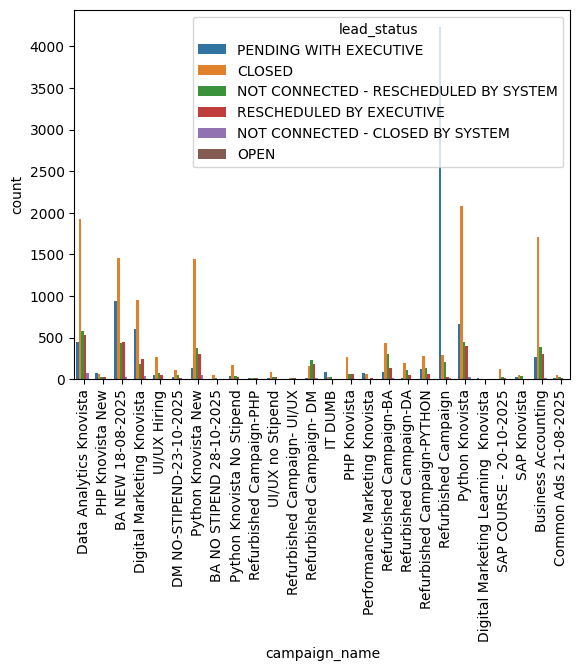

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='campaign_name',hue='lead_status',data=df)       #Graph is ploted campaign_name v/s lead_status
plt.xticks(rotation=90)
plt.show()

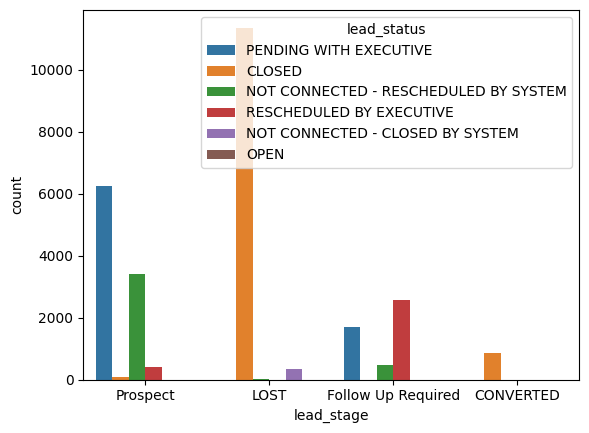

In [ ]:
sns.countplot(x='lead_stage',hue='lead_status',data=df)
plt.show()                                                #graph is drown lead_stage v/s lead_status

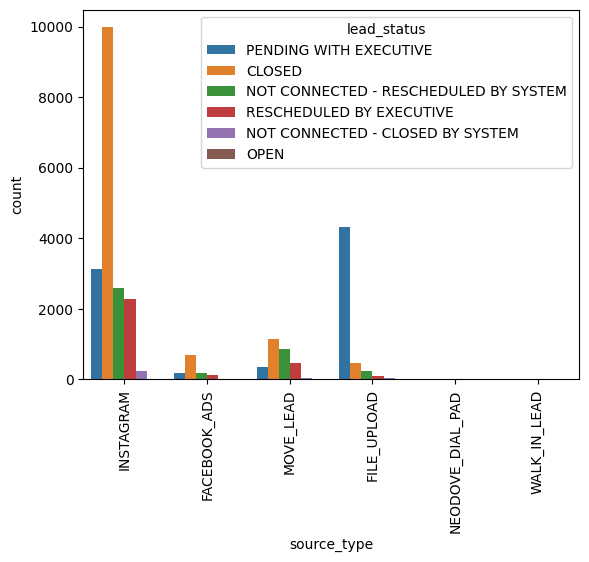

In [ ]:
sns.countplot(x='source_type',hue='lead_status',data=df)
plt.xticks(rotation=90)                            #graph is drawn source_type v/s lead_status
plt.show()

In [ ]:
df.columns

Index(['Name', 'contact_number', 'Contact_email', 'creation_date',
       'first_call_attempt', 'lead_status', 'lead_stage', 'lead_tag',
       'assigned_to', 'last_call_date', 'last_call_time', 'campaign_name',
       'source_type', 'source_name'],
      dtype='object')

In [ ]:
df.drop(['Name','contact_number','Contact_email','first_call_attempt','last_call_date','last_call_time'],axis=1,inplace=True) #unwanted columns for model prediction is removed

In [ ]:
df.drop('creation_date',axis=1,inplace=True)

In [ ]:
df['lead_status'].value_counts() #counts how many leads are in each status category.

,count
lead_status,
CLOSED,12279
PENDING WITH EXECUTIVE,7947
NOT CONNECTED - RESCHEDULED BY SYSTEM,3857
RESCHEDULED BY EXECUTIVE,2962
NOT CONNECTED - CLOSED BY SYSTEM,328
OPEN,2


In [ ]:
df['lead_status'] = df['lead_status'].str.strip()   #removes extra spaces from beginning and end of the text

In [ ]:
df['lead_status'] = df['lead_status'].apply(lambda x: 1 if x == 'CLOSED' else 0) # lambda function applied to convert the lead_status column to numeric

In [ ]:
df['lead_status'].value_counts()

,count
lead_status,
0,15096
1,12279


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27375 entries, 0 to 27374
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   lead_status    27375 non-null  int64 
 1   lead_stage     27375 non-null  object
 2   lead_tag       27375 non-null  object
 3   assigned_to    27375 non-null  object
 4   campaign_name  27375 non-null  object
 5   source_type    27375 non-null  object
 6   source_name    27375 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.5+ MB


In [ ]:
from sklearn.preprocessing import LabelEncoder      # categorical columns are converted to numeric using Labelencoder method

le = LabelEncoder()

categorical_cols = ['lead_stage','lead_tag','assigned_to','campaign_name','source_type','source_name']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
x=df.drop('lead_status',axis=1) #lead_status column removed
y=df['lead_status']

In [ ]:
from sklearn.model_selection import train_test_split       # values devided for training and testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)
x_train

,lead_stage,lead_tag,assigned_to,campaign_name,source_type,source_name
10505,2,6,11,5,2,10
4462,3,0,15,5,2,10
11082,3,0,5,18,3,14
921,2,6,17,24,2,10
1394,2,6,14,0,2,10
...,...,...,...,...,...,...
21575,3,0,4,15,1,23
5390,2,6,14,0,2,10
860,3,0,10,6,2,10
15795,1,3,4,5,2,10


In [ ]:
y_train

,lead_status
10505,1
4462,0
11082,0
921,1
1394,1
...,...
21575,0
5390,1
860,0
15795,0


In [ ]:
from sklearn.ensemble import RandomForestClassifier      #model created using RandomForestClassifier

model = RandomForestClassifier()

model.fit(x_train, y_train)
y_pred = model.predict(x_test)
y_pred

array([1, 1, 0, ..., 1, 1, 0])

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report     # model is evaluated using accuracy_score,confusion_matrix,classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9965907707293316
Confusion Matrix:
[[4529    6]
 [  22 3656]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4535
           1       1.00      0.99      1.00      3678

    accuracy                           1.00      8213
   macro avg       1.00      1.00      1.00      8213
weighted avg       1.00      1.00      1.00      8213



In [ ]:
new_lead = np.array([[2,1,3,0,2,5]])
prediction = model.predict(new_lead)
print(prediction)
if prediction[0] == 1:
    print("Lead will convert")        #takes a new lead’s details, sends it to the trained model and predicts whether the lead will convert into a customer
else:
    print("Lead will not convert")




[1]
Lead will convert


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


 I created a simple prediction system where new lead data is passed as input to the trained Random Forest model.
 The model predicts whether the lead will convert or not, and the result is displayed in a user-friendly format.